# C1. IR 메트릭 — hit@k와 MRR

| | |
|---|---|
| **트랙** | C 평가 |
| **선수 토픽** | — |
| **프로젝트 앵커** | `eval.py` · `hit@1` / `hit@3` / `h3_macro` |
| **작성일** | 2026-07-29 |
| **최종 검증** | 2026-07-29 |
| **상태** | 검증완료 |

## 한 줄 요약
> hit@k는 정답이 상위 $k$에 들었는지만 세는 계단 함수이고 MRR은 경계 안쪽 순위까지 재는
> 연속 지표라, 같은 두 검색기를 놓고도 어떤 자를 쓰느냐에 따라 승자가 바뀐다.

## 0. 준비

필요 패키지는 `numpy`, `matplotlib` 뿐이다. C1은 지표의 정의와 성질만 다루므로 실제 검색기나
평가셋 없이, 정답 순위 분포만으로 전부 재현된다. 프로젝트 실측치는 §3에서 인용만 하고
계산 가능한 숫자는 §4에서 직접 만든다.

In [1]:
# ── 표준 셋업 ────────────────────────────────────────────
from __future__ import annotations

import pathlib
import random

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ASSETS = pathlib.Path("../assets")
OUT = pathlib.Path("./out"); OUT.mkdir(exist_ok=True)
np.set_printoptions(precision=4, suppress=True)

# 팔레트 (FUNDAMENTAL 시리즈 공용)
C_MAIN, C_SUB, C_GRAY = "#ee4c2c", "#0d9488", "#94a3b8"

_installed = {f.name for f in fm.fontManager.ttflist}
for _f in ("AppleGothic", "Malgun Gothic", "NanumGothic"):
    if _f in _installed:
        mpl.rcParams["font.family"] = _f
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.figsize"] = (7, 4)
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

print(f"seed={SEED} · font={mpl.rcParams['font.family'][0]}")

seed=42 · font=sans-serif


## 1. 개념

### 랭킹 하나가 숫자 하나가 되기까지

검색기 평가는 질의 $q$에 대해 시스템이 내놓은 순위 리스트와 사람이 정한 정답 집합(gold)을
비교하는 일이다. gold가 질의당 청크 하나인 경우, 그 긴 리스트에서 필요한 정보는 사실상
**정답이 몇 번째에 있었는가** 하나로 압축된다. 이 값을 $r(q)$라 쓰고, 상위 $K$ 밖이면
$r(q) = \infty$로 둔다.

> **정의**  hit@k와 MRR은 같은 $r(q)$에서 갈라진다.
> $$\mathrm{hit@}k = \frac{1}{|Q|}\sum_{q \in Q} \mathbb{1}\!\left[r(q) \le k\right],
> \qquad
> \mathrm{MRR} = \frac{1}{|Q|}\sum_{q \in Q} \frac{1}{r(q)}$$

차이는 $r(q)$를 어떻게 취급하느냐에 있다. hit@k는 $k$에서 자른 **계단 함수**라 경계 안쪽의
순위 차이를 전부 버린다. 1위든 3위든 hit@3에는 똑같이 1로 들어간다. MRR은 순위의 역수를
그대로 쓰므로 안쪽 개선도 점수에 반영되지만, 대신 "몇 위 안에 들었는가"라는 운영상의 질문에는
직접 답하지 못한다. 0.61이라는 MRR 값에서 정답이 컨텍스트에 들어갔는지를 읽어낼 수는 없다.

### 계단이 정보를 버리는 게 손해만은 아니다

정보를 버리는 지표를 굳이 쓰는 이유는 그 경계가 시스템의 실제 경계와 일치할 때 생긴다.
생성 단계가 상위 3청크만 컨텍스트로 받는다면 4위에 있는 정답은 검색기 입장에서는 찾은 것이지만
답변 입장에서는 없는 것이다. hit@3은 이 "있음/없음"을 그대로 센다. MRR이 재는 4위와 5위의
차이는 이 파이프라인에서 아무것도 바꾸지 못한다.

### 이웃 지표들의 자리

| 지표 | gold 1개일 때의 값 | 쓰임 |
|---|---|---|
| recall@k | hit@k와 **동일** | gold가 여러 개일 때부터 갈라진다 |
| precision@k | $\mathrm{hit@}k / k$ | 순위 비교 결론은 hit@k와 같고 절대값만 작아진다 |
| nDCG@k | $1/\log_2(r+1)$ 형태 | 관련성에 등급이 있을 때 의미가 생긴다 |
| MRR | $1/r$ | 경계 안쪽 순위를 재는 유일한 값 |

> **함정**  gold가 질의당 1개라는 전제가 깨지는 순간 hit@k와 recall@k는 다른 값이 된다.
> 평가셋에 정답 청크를 2개 이상 단 문항이 섞여 있으면 지표 이름은 그대로인데 뜻이 조용히
> 바뀐다. §4-5에서 숫자로 확인한다.

### 어떤 $k$를 고를 것인가

지표 선택은 통계 문제가 아니라 제품 결정이다. $k$는 컨텍스트 창의 크기에서 따라오는 값이지
관례로 고르는 값이 아니다. hit@10은 컨텍스트에 들어가지도 않는 구간을 재므로 이 파이프라인에서는
의미가 없고, hit@1은 그보다 엄격한 보조 지표로서 리랭커처럼 순위 안쪽을 정리하는 변경의 효과를
감지하는 데 쓴다.

## 2. 최소 구현

지표 세 개는 전부 gold 순위 하나에서 파생된다. 랭킹 리스트에서 그 순위를 뽑는 함수 하나와,
거기서 갈라지는 계산 두 줄이면 끝이다. 아래 세 문항은 정답이 각각 2위·1위·랭킹 밖이라
세 지표가 서로 다른 값을 내도록 골랐다.

In [2]:
def gold_rank(ranked: list[str], gold: set[str]) -> int | None:
    """랭킹 리스트에서 gold가 처음 등장하는 순위(1-base). 없으면 None."""
    for r, doc_id in enumerate(ranked, start=1):
        if doc_id in gold:
            return r
    return None


def hit_at_k(rank: int | None, k: int) -> int:
    """gold가 상위 k 안에 있으면 1. 경계 안쪽 순위는 버려진다."""
    return int(rank is not None and rank <= k)


def reciprocal_rank(rank: int | None) -> float:
    """gold 순위의 역수. 못 찾으면 0으로 둔다."""
    return 0.0 if rank is None else 1.0 / rank


CASES = [
    (["c-19", "c-04", "c-11", "c-07"], {"c-04"}),   # gold 2위
    (["c-33", "c-02", "c-08", "c-15"], {"c-33"}),   # gold 1위
    (["c-05", "c-21", "c-40", "c-12"], {"c-09"}),   # 미검출
]

ranks = [gold_rank(r, g) for r, g in CASES]
print(f"gold 순위 : {ranks}")
print(f"hit@1     : {np.mean([hit_at_k(r, 1) for r in ranks]):.4f}")
print(f"hit@3     : {np.mean([hit_at_k(r, 3) for r in ranks]):.4f}")
print(f"MRR       : {np.mean([reciprocal_rank(r) for r in ranks]):.4f}")

gold 순위 : [2, 1, None]
hit@1     : 0.3333
hit@3     : 0.6667
MRR       : 0.5000


## 3. 프로젝트 앵커

`eval.py`는 평가셋을 돌며 질의마다 `search()` 결과에서 gold 청크의 순위를 찾고, 그 순위 하나에서
`hit@1`·`hit@3`·`h3_macro`를 만든다. 앞의 둘은 §2의 두 줄과 같은 계산이고, `h3_macro`는 평균을
내는 단위를 질의가 아니라 업무 구분으로 바꾼 것이다(C2).

hit@3이 1차 지표인 이유는 통계적 우월성이 아니라 파이프라인 구조다. 지표의 경계를 컨텍스트 창의
경계와 일치시킨 선택이며, 컨텍스트 크기가 바뀌면 지표도 같이 흔들린다는 뜻이기도 하다.

> **프로젝트**  하이브리드 기준 hit@3 = 0.945 (400문항 셋, `baseline_20260722.lock`).
> 같은 락에서 `FACET_BOOST`를 0.03에서 0.08로 올리면 0.953이 되는데, 이 +0.008이 실개선인지
> 표본 잡음인지는 hit@3 값 자체로는 판정되지 않는다(C3).

> **함정**  hit@3이 계단 함수라는 사실은 튜닝에도 그대로 영향을 준다. 정답을 5위에서 4위로
> 끌어올린 개선은 hit@3을 1도 움직이지 못한다. 지표가 평평했다는 것과 변경이 무효였다는 것은
> 다른 진술이다.

> **프로젝트**  A7 검토에서 로컬 cross-encoder를 얹었을 때 hit@1이 0.567 → 0.707로 올랐다
> (측정 조건 미기재 — 원 실험 락 확인 필요). hit@1만 크게 움직였다는 건 정답이 이미 상위권에는
> 있었으나 1위가 아니었던 문항이 많았다는 뜻이고, 이런 종류의 변경은 hit@3에는 거의 나타나지
> 않는 게 정상이다. 반대로 MMR은 hit@3 기준 −0.143으로 완패해 기각됐다(A6).

같은 변경이 지표에 따라 크게 보이기도 하고 보이지 않기도 한다면, 지표를 하나만 보는 상태에서
내린 채택·기각 판단은 전부 재검토 대상이 된다. §4는 그 뒤집힘이 인위적 사례가 아니라 지표의
정의에서 곧바로 따라오는 성질임을 숫자로 확인한다.

## 4. 숫자 검증

실제 검색기 대신 **gold 순위의 분포**로 시스템을 정의한다. 이렇게 하면 임베딩·토크나이저 같은
변수를 전부 걷어내고 지표의 성질만 분리해서 볼 수 있다.

### 4-1. 세 지표, 세 결론

두 시스템을 만든다. A는 1위를 많이 맞히지만 놓칠 때 크게 놓치는 상위권 집중형이고, B는 1위는
적어도 3위 안에는 대부분 넣는 안정형이다. 5위 밖은 어차피 컨텍스트에 못 들어가므로 미검출로
묶어 $1/r$ 기여를 0으로 둔다.

In [3]:
# 순위 1~5의 확률. 합이 1보다 작고, 나머지 질량은 미검출(RR 기여 0)이다.
DIST = {
    "A": np.array([0.55, 0.05, 0.05, 0.05, 0.05]),
    "B": np.array([0.40, 0.25, 0.20, 0.05, 0.05]),
}
NOTE = {"A": "상위권 집중형", "B": "3위권 안정형"}
RANKS = np.arange(1, 6)


def expected_metrics(p: np.ndarray) -> dict[str, float]:
    """순위 분포에서 hit@1·hit@3·MRR의 기댓값을 해석적으로 계산한다."""
    return {"hit@1": float(p[0]), "hit@3": float(p[:3].sum()),
            "MRR": float(p @ (1 / RANKS))}


exp = {name: expected_metrics(p) for name, p in DIST.items()}

print(f"{'sys':<5}{'hit@1':>9}{'hit@3':>9}{'MRR':>9}{'miss':>9}   note")
print("-" * 55)
for name, p in DIST.items():
    m = exp[name]
    print(f"{name:<5}{m['hit@1']:>9.4f}{m['hit@3']:>9.4f}{m['MRR']:>9.4f}"
          f"{1 - p.sum():>9.4f}   {NOTE[name]}")

gap = {k: exp["B"][k] - exp["A"][k] for k in ("hit@1", "hit@3", "MRR")}
print("\nB - A :", " · ".join(f"{k} {v if abs(v) > 5e-5 else 0.0:+.4f}"
                              for k, v in gap.items()))

sys      hit@1    hit@3      MRR     miss   note
-------------------------------------------------------
A       0.5500   0.6500   0.6142   0.2500   상위권 집중형
B       0.4000   0.8500   0.6142   0.0500   3위권 안정형

B - A : hit@1 -0.1500 · hit@3 +0.2000 · MRR +0.0000


MRR이 소수점 넷째 자리까지 완전히 같은데 hit@1은 A가, hit@3은 B가 이긴다. 세 지표가
같은 데이터에서 **이긴다 · 진다 · 비긴다** 세 결론을 동시에 낸 것이다. 어느 하나가 틀린 게
아니라, 셋이 애초에 서로 다른 질문에 답하고 있다.

### 4-2. $k$를 움직이면 승자가 바뀐다

같은 분포에서 $k$를 1부터 5까지 옮겨가며 hit@k를 그린다.

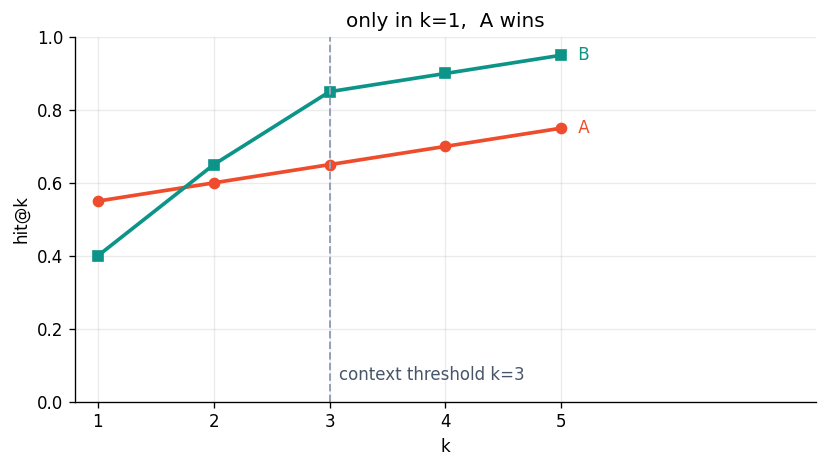

In [10]:
hitk = {name: np.cumsum(p) for name, p in DIST.items()}

fig, ax = plt.subplots()
ax.plot(RANKS, hitk["A"], "o-", color=C_MAIN, lw=2.2)
ax.plot(RANKS, hitk["B"], "s-", color=C_SUB, lw=2.2)
ax.text(5.1, hitk["A"][-1], " A ", color=C_MAIN, va="center", fontsize=10)
ax.text(5.1, hitk["B"][-1], " B ", color=C_SUB, va="center", fontsize=10)

ax.axvline(3, color=C_GRAY, ls="--", lw=1.2)
ax.text(3.08, 0.06, "context threshold k=3", color="#475569", fontsize=10)

ax.set_xlabel("k")
ax.set_ylabel("hit@k")
ax.set_ylim(0, 1)
ax.set_xlim(0.8, 7.2)
ax.set_xticks(RANKS)
ax.set_title("only in k=1,  A wins")
plt.tight_layout()
plt.show()

두 곡선은 $k=1$과 $k=2$ 사이에서 교차한다. 어느 $k$를 1차 지표로 삼느냐에 따라 "A 채택"과
"B 채택"이 둘 다 데이터에 근거한 결론이 된다. $k$를 컨텍스트 크기에서 유도해야 한다는 §1의
주장은 미학이 아니라 이 교차점을 임의로 고르지 않기 위한 장치다.

### 4-3. 기댓값과 실측값은 다르다

위 값들은 분포에서 계산한 기댓값이다. 실제 평가는 유한한 문항 수 위에서 이뤄지므로 같은
시스템이라도 셋을 다시 뽑으면 값이 흔들린다. 400문항 셋을 200번 다시 뽑아 그 폭을 잰다.

In [5]:
rng = np.random.default_rng(SEED)
N_ITEM, N_REPEAT, MISS = 400, 200, 99          # MISS는 5위 밖을 나타내는 코드값


def sample_metrics(p: np.ndarray, n: int) -> dict[str, float]:
    """분포에서 n문항을 뽑아 실측 지표를 계산한다."""
    drawn = rng.choice(np.append(RANKS, MISS), size=n, p=np.append(p, 1 - p.sum()))
    return {"hit@1": float((drawn <= 1).mean()), "hit@3": float((drawn <= 3).mean()),
            "MRR": float(np.where(drawn == MISS, 0.0, 1 / drawn).mean())}


print(f"{'sys':<5}{'metric':<8}{'expected':>10}{'mean':>9}{'2.5%':>9}{'97.5%':>9}{'width':>9}")
print("-" * 59)
for name, p in DIST.items():
    sims = [sample_metrics(p, N_ITEM) for _ in range(N_REPEAT)]
    for key in ("hit@1", "hit@3", "MRR"):
        vals = np.array([s[key] for s in sims])
        lo, hi = np.percentile(vals, [2.5, 97.5])
        print(f"{name:<5}{key:<8}{exp[name][key]:>10.4f}{vals.mean():>9.4f}"
              f"{lo:>9.4f}{hi:>9.4f}{hi - lo:>9.4f}")

sys  metric    expected     mean     2.5%    97.5%    width
-----------------------------------------------------------
A    hit@1       0.5500   0.5481   0.5049   0.5950   0.0901
A    hit@3       0.6500   0.6482   0.6049   0.6876   0.0826
A    MRR         0.6142   0.6125   0.5709   0.6538   0.0830
B    hit@1       0.4000   0.4002   0.3574   0.4476   0.0901
B    hit@3       0.8500   0.8489   0.8149   0.8776   0.0626
B    MRR         0.6142   0.6144   0.5831   0.6464   0.0633


400문항에서도 95% 구간의 폭이 지표당 0.06~0.09에 이른다. §3에서 인용한 `FACET_BOOST`
스윕의 +0.008은 이 폭의 10분의 1 수준이므로, 그 숫자만으로 개선을 주장할 수 없다는 게
여기서 이미 드러난다. 판정 도구 자체는 C3에서 만든다.

### 4-4. 어느 구간의 개선을 감지하는가

지표가 순위 변화에 반응하는지는 **그 변화가 어느 구간에서 일어났는가**에 달렸다.
100문항 셋에서 질의 하나의 gold 순위가 한 칸 올라갔을 때 각 지표가 받는 변화량을 계산한다.

In [6]:
N_BASE = 100
MOVES = [(5, 4), (4, 3), (3, 2), (2, 1)]

print(f"{'move':>8}{'d hit@1':>11}{'d hit@3':>11}{'d MRR':>11}")
print("-" * 41)
for before, after in MOVES:
    d1 = (hit_at_k(after, 1) - hit_at_k(before, 1)) / N_BASE
    d3 = (hit_at_k(after, 3) - hit_at_k(before, 3)) / N_BASE
    dm = (reciprocal_rank(after) - reciprocal_rank(before)) / N_BASE
    print(f"{f'{before} -> {after}':>8}{d1:>11.4f}{d3:>11.4f}{dm:>11.4f}")

print("\nhit@3은 4->3 한 칸에서만, hit@1은 2->1 한 칸에서만 움직인다.")

    move    d hit@1    d hit@3      d MRR
-----------------------------------------
  5 -> 4     0.0000     0.0000     0.0005
  4 -> 3     0.0000     0.0100     0.0008
  3 -> 2     0.0000     0.0000     0.0017
  2 -> 1     0.0100     0.0000     0.0050

hit@3은 4->3 한 칸에서만, hit@1은 2->1 한 칸에서만 움직인다.


hit@3은 네 번의 개선 중 한 번만, hit@1도 한 번만 반응한다. 나머지 두 번의 개선은 두 지표
모두에게 **일어나지 않은 일**이다. MRR은 네 번 모두 반응하며 상위권으로 갈수록 반응이 커진다
(0.0005 → 0.0050, 10배).

리랭커처럼 상위 후보의 순서만 바꾸는 변경이 hit@1에서만 크게 보이는 이유가 여기 있다.
§3의 0.567 → 0.707은 2위권에 몰려 있던 정답이 1위로 올라온 사건이며, 같은 변경이 hit@3에
안 잡히는 것은 리랭커가 무력해서가 아니라 hit@3이 그 구간에 눈이 없어서다.

### 4-5. gold가 늘어나면 이름이 같은 지표가 달라진다

§1의 함정을 확인한다. 정답 청크 3개짜리 문항 하나를 놓고 세 지표를 나란히 계산한다.

In [7]:
ranked = ["c-11", "c-04", "c-27", "c-08", "c-15"]
gold_multi = {"c-04", "c-15", "c-31"}          # c-31은 랭킹 5위 밖

print(f"{'k':>3}{'hit@k':>8}{'recall@k':>11}{'precision@k':>13}")
print("-" * 35)
for k in (1, 3, 5):
    found = len(gold_multi & set(ranked[:k]))
    print(f"{k:>3}{int(found > 0):>8}{found / len(gold_multi):>11.4f}{found / k:>13.4f}")

print("\nhit@3 == hit@5 == 1 이지만 recall은 0.3333 -> 0.6667로 다르다.")

  k   hit@k   recall@k  precision@k
-----------------------------------
  1       0     0.0000       0.0000
  3       1     0.3333       0.3333
  5       1     0.6667       0.4000

hit@3 == hit@5 == 1 이지만 recall은 0.3333 -> 0.6667로 다르다.


hit@k는 gold가 여러 개여도 "적어도 하나 찾았는가"만 세므로 $k=3$과 $k=5$에서 값이 같지만,
recall@k는 두 배 차이를 낸다. 평가셋에 gold 복수 문항이 섞여 있는데 리포트에 `hit@3`이라고만
적혀 있다면, 그 숫자는 recall이 아니라 **적어도 하나 지표**라는 사실이 어딘가에 명시돼 있어야
한다.

§4 전체를 한 줄로 줄이면 이렇다. 지표는 측정 도구가 아니라 **질문**이며, 질문을 하나만 던져 놓고
답이 하나로 나왔다고 안심하는 것이 평가에서 가장 흔한 실수다. 이후 노트북에서 "이게 최선이었나"를
물을 때, 그 판단이 어느 질문 위에 서 있는지를 먼저 적어야 하는 이유가 여기 있다.

## 5. 남은 질문

- `eval.py` 리포트에 MRR이 포함돼 있는데, 주 평가는 hit@3으로만 이루어졌었다. 이는 4-4에서 본 사각지대(5→4, 3→2
  구간)를 실제 평가셋이 얼마나 자주 밟는지가 추가 여부의 판단 근거가 된다.
- 평가셋에 gold가 2개 이상인 문항이 몇 건인지 세야 한다. 섞여 있다면 현재 `hit@3`은 recall@3이
  아니며, 그 해석이 리포트에 적혀 있어야 한다(C5).
- 컨텍스트를 3청크에서 5청크로 늘리면 1차 지표도 hit@5로 따라가야 하는가? 지표가 설정을 따라가면
  이전 락과의 시계열 비교가 끊긴다. 어느 쪽 비용이 큰지는 아직 답이 없다.
- 4-1의 두 분포는 MRR이 정확히 같아지도록 만든 구성이다. 실제 검색기 두 개에서 이런 완전한
  상쇄가 관측될 확률은 낮은데, 그렇다면 이 사례는 교육용 극단값인가 아니면 실제로 조심해야 할
  패턴인가? 프로젝트 로그의 모드별 순위 분포를 뽑아 봐야 판단할 수 있다.
- A7 리랭커를 재검토한다면 hit@1 하나로 효과를 판정할 것인가? 4-4 기준으로 hit@1은 2→1 한 칸에만
  반응하므로, 3→2로만 올라간 문항들의 개선은 보이지 않은 채 남는다.

## 참고

- Manning, Raghavan & Schütze (2008), *Introduction to Information Retrieval* 8장 — 평가 지표 정의
- Voorhees (1999), *The TREC-8 Question Answering Track Report* — MRR이 표준 지표가 된 배경
- Järvelin & Kekäläinen (2002), *Cumulated Gain-based Evaluation of IR Techniques* — nDCG 원논문
- [BEIR](https://github.com/beir-cellar/beir) — 검색 평가 프로토콜의 참고 구현
- 프로젝트: `eval.py`, `baseline_20260722.lock`